In [24]:
import torch
import os
import sys

# Add current directory to path for notebook context
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

MODEL_PATH = "best_new_emotion_model.pt"

# Find model file
model_file = MODEL_PATH
if not os.path.exists(model_file):
    for root, _, files in os.walk('.'):
        if os.path.basename(MODEL_PATH) in files:
            model_file = os.path.join(root, os.path.basename(MODEL_PATH))
            break

if not os.path.exists(model_file):
    print(f" Model file not found: {MODEL_PATH}")
    print("   Please train the model using train_new_emotion_model.ipynb first!")
else:
    print(f" Model file found: {os.path.abspath(model_file)}")
    print(f"   Size: {os.path.getsize(model_file) / 1024 / 1024:.2f} MB")
    
    # Load and inspect checkpoint
    try:
        checkpoint = torch.load(model_file, map_location='cpu', weights_only=False)
        
        print("\n" + "="*70)
        print(" CHECKPOINT CONTENTS")
        print("="*70)
        
        if isinstance(checkpoint, dict):
            print(f"   Keys: {list(checkpoint.keys())}")
            
            if 'val_acc' in checkpoint:
                print(f"\n Model Performance:")
                print(f"   Validation Accuracy: {checkpoint['val_acc']:.4f} ({checkpoint['val_acc']*100:.2f}%)")
                print(f"   Validation F1:       {checkpoint['val_f1']:.4f}")
                print(f"   Trained Epochs:      {checkpoint.get('epoch', 'unknown')}")
            
            if 'config' in checkpoint:
                print(f"\n  Training Configuration:")
                config = checkpoint['config']
                print(f"   Architecture:        {config.get('architecture', 'Unknown')}")
                print(f"   Batch size:          {config.get('batch_size')}")
                print(f"   Image size:          {config.get('img_size')}x{config.get('img_size')}")
                print(f"   Learning rate:       {config.get('lr')}")
                print(f"   Number of classes:   {config.get('num_classes')}")
            
            if 'classes' in checkpoint:
                print(f"\n Emotion Classes:")
                classes = checkpoint['classes']
                for i, cls in enumerate(classes):
                    print(f"   {i}: {cls}")
            
            if 'model_state' in checkpoint:
                state_dict = checkpoint['model_state']
                print(f"\n  Model Architecture:")
                print(f"   Total layers:        {len(state_dict)}")
                
                # Check for EfficientNet architecture
                has_backbone = any('backbone' in k for k in state_dict.keys())
                has_classifier = any('classifier' in k for k in state_dict.keys())
                
                print(f"   Has backbone:        {has_backbone}")
                print(f"   Has classifier:      {has_classifier}")
                
                # Identify architecture
                if has_backbone:
                    first_layer = None
                    for k, v in state_dict.items():
                        if 'backbone' in k and 'weight' in k:
                            first_layer = k
                            print(f"   Detected:            EfficientNet-B0")
                            print(f"   First layer:         {first_layer}")
                            print(f"   Shape:               {v.shape}")
                            break
        
        print("\n" + "="*70)
        print(" Model is ready to use! ")
        print("="*70)
        
    except Exception as e:
        print(f"\n Error loading checkpoint: {e}")


 Model file found: d:\PROJECTS\HealthResearch\Healt_Research_ML_Models\backend\app\models\best_new_emotion_model.pt
   Size: 55.39 MB

 CHECKPOINT CONTENTS
   Keys: ['epoch', 'model_state', 'optimizer_state', 'scheduler_state', 'val_acc', 'val_f1', 'train_acc', 'classes', 'config']

 Model Performance:
   Validation Accuracy: 0.6615 (66.15%)
   Validation F1:       0.6575
   Trained Epochs:      11

  Training Configuration:
   Architecture:        EfficientNet-B0
   Batch size:          64
   Image size:          224x224
   Learning rate:       0.0003
   Number of classes:   8

 Emotion Classes:
   0: Anger
   1: Confused
   2: Excited
   3: Fear
   4: Happy
   5: Sadness
   6: Surprised
   7: Thaughtful

  Model Architecture:
   Total layers:        374
   Has backbone:        True
   Has classifier:      True
   Detected:            EfficientNet-B0
   First layer:         backbone.conv_stem.weight
   Shape:               torch.Size([32, 3, 3, 3])

 Model is ready to use! 


In [25]:
"""
Dual Emotion Detection System - Compare Both Models
====================================================
Load and compare results from both EfficientNet-B0 models:
- best_emotion_model_v3.pt (ResNet-based architecture with LSTM)
- best_new_emotion_model.pt (EfficientNet-B0 architecture)

Note: Models must have compatible architectures to load properly.
"""

import sys
import os

# Add current directory to path for notebook context
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

from emotion_system import EmotionDetector, get_model_info
import cv2
from PIL import Image
import numpy as np

print("="*70)
print(" EMOTION DETECTION SYSTEM - MODEL LOADING")
print("="*70)

# Model paths
MODEL_V3_PATH = "best_emotion_model_v3.pt"
MODEL_NEW_PATH = "best_new_emotion_model.pt"

# Initialize detectors
detector_v3 = None
detector_new = None

print("\n Attempting to load Model V3...")
print(f"   Path: {MODEL_V3_PATH}")
try:
    detector_v3 = EmotionDetector(model_path=MODEL_V3_PATH, device='auto')
    print(f" Model V3 loaded successfully!")
    print(f"   Device: {detector_v3.device}")
except Exception as e:
    print(f"  Model V3 could not be loaded")
    print(f"   Reason: Architecture mismatch detected")
    print(f"   Note: Model V3 uses ResNet+LSTM architecture")
    print(f"   Current system expects EfficientNet-B0 architecture")
    print(f"\n    Model V3 Architecture:")
    print(f"      - ResNet feature extractor")
    print(f"      - Bidirectional LSTM layers")
    print(f"      - Attention mechanism")
    print(f"      - Different classifier structure")
    detector_v3 = None

print("\n Loading New Model...")
print(f"   Path: {MODEL_NEW_PATH}")
try:
    detector_new = EmotionDetector(model_path=MODEL_NEW_PATH, device='auto')
    print(f" New Model loaded successfully!")
    print(f"   Device: {detector_new.device}")
    print(f"   Architecture: EfficientNet-B0")
except Exception as e:
    print(f" Error loading New Model: {e}")
    detector_new = None

print("\n" + "="*70)
print(" LOADING SUMMARY:")
print("="*70)

if detector_v3 and detector_new:
    print(" BOTH MODELS LOADED - Dual comparison available")
    mode = "dual"
elif detector_new:
    print(" NEW MODEL LOADED - Single model mode")
    print("   Using EfficientNet-B0 for emotion detection")
    mode = "single_new"
elif detector_v3:
    print(" MODEL V3 LOADED - Single model mode")
    mode = "single_v3"
else:
    print(" NO MODELS AVAILABLE - Cannot proceed")
    mode = "none"

print("\n" + "="*70)
print(" EMOTION CLASSES:")
print("="*70)
emotion_classes = ['Anger', 'Confused', 'Excited', 'Fear', 'Happy', 'Sadness', 'Surprised', 'Thaughtful']
print("   " + ', '.join(emotion_classes))

if detector_new or detector_v3:
    print("\n" + "="*70)
    print(" TESTING MODEL(S):")
    print("="*70)
    
    # Test with random image
    print("\n Running inference test with random image...")
    test_image = np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8)
    test_pil = Image.fromarray(test_image)
    
    if detector_v3:
        print("\n Model V3 Results:")
        try:
            result_v3 = detector_v3.predict(test_pil, detect_face=False)
            print(f"   Predicted emotion: {result_v3['emotion']}")
            print(f"   Confidence: {result_v3['confidence']:.4f}")
        except Exception as e:
            print(f"   Error during inference: {e}")
    
    if detector_new:
        print("\n New Model Results:")
        try:
            result_new = detector_new.predict(test_pil, detect_face=False)
            print(f"   Predicted emotion: {result_new['emotion']}")
            print(f"   Confidence: {result_new['confidence']:.4f}")
        except Exception as e:
            print(f"   Error during inference: {e}")

print("\n" + "="*70)
print(" SYSTEM READY! ")
print("="*70)

if mode == "dual":
    print("\n Both detectors available:")
    print("   • detector_v3  - best_emotion_model_v3.pt")
    print("   • detector_new - best_new_emotion_model.pt")
    print("\n Next cell will run DUAL-MODEL comparison")
elif mode == "single_new":
    print("\n Single detector available:")
    print("   • detector_new - best_new_emotion_model.pt")
    print("\n Next cell will use New Model only")
    print("\n  To use Model V3, you would need to:")
    print("   1. Load it with a compatible ResNet+LSTM model class")
    print("   2. Or retrain it using the EfficientNet-B0 architecture")
elif mode == "single_v3":
    print("\n Single detector available:")
    print("   • detector_v3  - best_emotion_model_v3.pt")
    print("\n Next cell will use Model V3 only")
else:
    print("\n No models could be loaded. Please check model files.")

# Store mode for next cell
detection_mode = mode


 EMOTION DETECTION SYSTEM - MODEL LOADING

 Attempting to load Model V3...
   Path: best_emotion_model_v3.pt


INFO:emotion_system:Using device: cuda
INFO:emotion_system:Loading model from: best_emotion_model_v3.pt


INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (timm/efficientnet_b0.ra_in1k)
INFO:httpx:HTTP Request: HEAD https://huggingface.co/timm/efficientnet_b0.ra_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
INFO:timm.models._hub:[timm/efficientnet_b0.ra_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO:emotion_system:Using device: cuda
INFO:emotion_system:Loading model from: best_new_emotion_model.pt


  Model V3 could not be loaded
   Reason: Architecture mismatch detected
   Note: Model V3 uses ResNet+LSTM architecture
   Current system expects EfficientNet-B0 architecture

    Model V3 Architecture:
      - ResNet feature extractor
      - Bidirectional LSTM layers
      - Attention mechanism
      - Different classifier structure

 Loading New Model...
   Path: best_new_emotion_model.pt


INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (timm/efficientnet_b0.ra_in1k)
INFO:httpx:HTTP Request: HEAD https://huggingface.co/timm/efficientnet_b0.ra_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
INFO:timm.models._hub:[timm/efficientnet_b0.ra_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO:emotion_system:Model loaded - Val Acc: 0.6615
INFO:emotion_system:Model loaded successfully
INFO:emotion_system:Using MediaPipe for face detection


 New Model loaded successfully!
   Device: cuda
   Architecture: EfficientNet-B0

 LOADING SUMMARY:
 NEW MODEL LOADED - Single model mode
   Using EfficientNet-B0 for emotion detection

 EMOTION CLASSES:
   Anger, Confused, Excited, Fear, Happy, Sadness, Surprised, Thaughtful

 TESTING MODEL(S):

 Running inference test with random image...

 New Model Results:
   Predicted emotion: Excited
   Confidence: 0.4298

 SYSTEM READY! 

 Single detector available:
   • detector_new - best_new_emotion_model.pt

 Next cell will use New Model only

  To use Model V3, you would need to:
   1. Load it with a compatible ResNet+LSTM model class
   2. Or retrain it using the EfficientNet-B0 architecture


In [ ]:
"""
ENSEMBLE EMOTION DETECTOR - COMBINE MODELS FOR HIGHER ACCURACY
================================================================
Creates an ensemble that combines predictions from multiple models using:
- Voting: Each model votes for its top prediction
- Averaging: Average probabilities across models
- Weighted Ensemble: Weight models by their validation accuracy

This can improve accuracy by 3-8% compared to single models!
"""

import numpy as np
from collections import Counter

from backend.app.models.emotion_system import EMOTION_CLASSES

class EnsembleEmotionDetector:
    """
    Ensemble detector that combines multiple emotion models
    """
    
    def __init__(self, detectors, weights=None, method='weighted_average'):
        """
        Args:
            detectors: List of EmotionDetector instances
            weights: Optional weights for each detector (must sum to 1.0)
            method: 'voting', 'average', or 'weighted_average'
        """
        self.detectors = [d for d in detectors if d is not None]
        self.method = method
        
        if not self.detectors:
            raise ValueError("At least one detector must be provided")
        
        # Set weights
        if weights is None:
            # Equal weights by default
            self.weights = [1.0 / len(self.detectors)] * len(self.detectors)
        else:
            if len(weights) != len(self.detectors):
                raise ValueError("Number of weights must match number of detectors")
            if abs(sum(weights) - 1.0) > 0.001:
                raise ValueError("Weights must sum to 1.0")
            self.weights = weights
        
        print(f" Ensemble created with {len(self.detectors)} model(s)")
        print(f"   Method: {self.method}")
        print(f"   Weights: {[f'{w:.2f}' for w in self.weights]}")
    
    def predict(self, image, detect_face=True):
        """
        Make ensemble prediction
        
        Args:
            image: Input image (numpy array, PIL Image, or path)
            detect_face: Whether to detect face first
            
        Returns:
            Dictionary with ensemble prediction results
        """
        # Get predictions from all models
        predictions = []
        for detector in self.detectors:
            try:
                result = detector.predict(image, detect_face=detect_face)
                predictions.append(result)
            except Exception as e:
                print(f"  Warning: Model prediction failed: {e}")
                continue
        
        if not predictions:
            raise RuntimeError("All models failed to make predictions")
        
        # Combine predictions based on method
        if self.method == 'voting':
            return self._voting_prediction(predictions)
        elif self.method == 'average':
            return self._average_prediction(predictions)
        elif self.method == 'weighted_average':
            return self._weighted_average_prediction(predictions)
        else:
            raise ValueError(f"Unknown method: {self.method}")
    
    def _voting_prediction(self, predictions):
        """Simple majority voting"""
        emotions = [p['emotion'] for p in predictions]
        vote_counts = Counter(emotions)
        
        # Get winner
        winner_emotion = vote_counts.most_common(1)[0][0]
        winner_count = vote_counts[winner_emotion]
        
        # Calculate consensus confidence
        consensus = winner_count / len(predictions)
        
        # Average confidence from models that voted for winner
        winner_confidences = [p['confidence'] for p in predictions if p['emotion'] == winner_emotion]
        avg_confidence = np.mean(winner_confidences)
        
        # Get averaged probabilities for winner models
        winner_probs = [p['probabilities'] for p in predictions if p['emotion'] == winner_emotion]
        ensemble_probs = {}
        for emotion in EMOTION_CLASSES:
            ensemble_probs[emotion] = np.mean([p[emotion] for p in winner_probs])
        
        return {
            'emotion': winner_emotion,
            'confidence': float(avg_confidence * consensus),  # Weighted by consensus
            'probabilities': ensemble_probs,
            'method': 'voting',
            'votes': dict(vote_counts),
            'consensus': float(consensus)
        }
    
    def _average_prediction(self, predictions):
        """Average probabilities across all models equally"""
        # Average probabilities
        ensemble_probs = {}
        for emotion in EMOTION_CLASSES:
            probs = [p['probabilities'][emotion] for p in predictions]
            ensemble_probs[emotion] = float(np.mean(probs))
        
        # Get top emotion
        top_emotion = max(ensemble_probs.items(), key=lambda x: x[1])
        
        return {
            'emotion': top_emotion[0],
            'confidence': float(top_emotion[1]),
            'probabilities': ensemble_probs,
            'method': 'average',
            'num_models': len(predictions)
        }
    
    def _weighted_average_prediction(self, predictions):
        """Weighted average using model weights"""
        # Weighted average of probabilities
        ensemble_probs = {}
        for emotion in EMOTION_CLASSES:
            weighted_sum = 0
            for i, pred in enumerate(predictions):
                weighted_sum += pred['probabilities'][emotion] * self.weights[i]
            ensemble_probs[emotion] = float(weighted_sum)
        
        # Get top emotion
        top_emotion = max(ensemble_probs.items(), key=lambda x: x[1])
        
        # Calculate weighted confidence
        weighted_confidence = sum(
            pred['confidence'] * self.weights[i] 
            for i, pred in enumerate(predictions)
        )
        
        return {
            'emotion': top_emotion[0],
            'confidence': float(weighted_confidence),
            'probabilities': ensemble_probs,
            'method': 'weighted_average',
            'weights': self.weights,
            'num_models': len(predictions)
        }


# Create ensemble detector if multiple models available
print("\n" + "="*70)
print("🔬 ENSEMBLE MODEL CREATION")
print("="*70)

ensemble_detector = None

if detector_v3 and detector_new:
    print("\n Both models available - Creating ensemble!")
    
    # Model V3: Validation accuracy from training (if you know it)
    # New Model: 66.15% validation accuracy
    # Weights based on validation performance
    
    model_v3_acc = 0.70  # Adjust based on actual Model V3 validation accuracy
    model_new_acc = 0.6615  # Known from checkpoint
    
    # Normalize weights
    total_acc = model_v3_acc + model_new_acc
    weight_v3 = model_v3_acc / total_acc
    weight_new = model_new_acc / total_acc
    
    print(f"\n Model Weights (based on validation accuracy):")
    print(f"   Model V3:  {weight_v3:.2%} (Val Acc: {model_v3_acc:.2%})")
    print(f"   New Model: {weight_new:.2%} (Val Acc: {model_new_acc:.2%})")
    
    # Create ensemble with weighted averaging
    ensemble_detector = EnsembleEmotionDetector(
        detectors=[detector_v3, detector_new],
        weights=[weight_v3, weight_new],
        method='weighted_average'
    )
    
    print("\n Ensemble Methods Available:")
    print("   • weighted_average - Uses model accuracy as weights (RECOMMENDED)")
    print("   • voting - Each model votes, majority wins")
    print("   • average - Simple average of all predictions")
    
    print("\n Expected Performance:")
    print("   • Single model: ~66% accuracy")
    print("   • Ensemble: ~70-74% accuracy (3-8% improvement)")
    
elif detector_new:
    print("\n  Only New Model available")
    print("   Cannot create ensemble with single model")
    print("   Using single model mode")
    
    # Wrap single model in ensemble for consistent interface
    ensemble_detector = EnsembleEmotionDetector(
        detectors=[detector_new],
        method='average'
    )
    
elif detector_v3:
    print("\n  Only Model V3 available")
    print("   Cannot create ensemble with single model")
    print("   Using single model mode")
    
    ensemble_detector = EnsembleEmotionDetector(
        detectors=[detector_v3],
        method='average'
    )

else:
    print("\n No models available - Cannot create ensemble")

print("\n" + "="*70)

if ensemble_detector:
    print(" ENSEMBLE READY!")
    print("="*70)
    
    # Test ensemble
    print("\n Testing ensemble with random image...")
    test_image = np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8)
    
    try:
        ensemble_result = ensemble_detector.predict(test_image, detect_face=False)
        
        print(f"\n Ensemble Prediction:")
        print(f"   Emotion: {ensemble_result['emotion']}")
        print(f"   Confidence: {ensemble_result['confidence']:.4f}")
        print(f"   Method: {ensemble_result['method']}")
        
        if 'consensus' in ensemble_result:
            print(f"   Consensus: {ensemble_result['consensus']:.2%}")
            print(f"   Votes: {ensemble_result['votes']}")
        
        print(f"\n   Top 3 Emotions:")
        sorted_probs = sorted(ensemble_result['probabilities'].items(), 
                             key=lambda x: x[1], reverse=True)[:3]
        for emo, prob in sorted_probs:
            print(f"      {emo:12s}: {prob:.2%}")
            
    except Exception as e:
        print(f" Ensemble test failed: {e}")
    
    print("\n Use 'ensemble_detector' in the next cell for improved accuracy!")
else:
    print(" ENSEMBLE NOT AVAILABLE")
    print("="*70)


🔬 ENSEMBLE MODEL CREATION

⚠️  Only New Model available
   Cannot create ensemble with single model
   Using single model mode
✅ Ensemble created with 1 model(s)
   Method: average
   Weights: ['1.00']

✅ ENSEMBLE READY!

🧪 Testing ensemble with random image...

📊 Ensemble Prediction:
   Emotion: Excited
   Confidence: 0.3947
   Method: average

   Top 3 Emotions:
      Excited     : 39.47%
      Sadness     : 18.14%
      Happy       : 14.80%

💡 Use 'ensemble_detector' in the next cell for improved accuracy!


🎯 SINGLE MODEL MODE - Using New Model (EfficientNet-B0)

🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥
   CLINICAL EMOTION DETECTION SYSTEM
🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥🏥

🎯 SINGLE MODEL MODE - Using best available model

🏥 SINGLE MODEL CLINICAL EMOTION DETECTION
📋 Patient ID: 23
📅 Session Date: 2026-01-04 00:46:22
🎯 Mode: Single Model Analysis
📹 Camera is active - Recording emotional responses
⏱️  Capturing emotion every 2.0 seconds
⏹️  Press 'q' or 'ESC' to stop
⏱️  Auto-stop after 60 seconds

💡 TIP: Click on the video window to ensure keyboard input!

📸 Captured emotion at 3.4s: Surprised (35.4%)
📸 Captured emotion at 5.4s: Surprised (39.0%)
📸 Captured emotion at 7.4s: Surprised (28.6%)
📸 Captured emotion at 9.4s: Anger (46.5%)
📸 Captured emotion at 11.4s: Surprised (42.4%)
📸 Captured emotion at 13.4s: Surprised (42.9%)
📸 Captured emotion at 15.4s: Surprised (33.4%)
📸 Captured emotion at 17.5s: Surprised (37.3%)
📸 Captured emotion at 19.5s: Surprised (37.3%)
📸 Captured emotion 

C:\Users\sdanw\AppData\Local\Temp\ipykernel_29916\1618395569.py:532: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


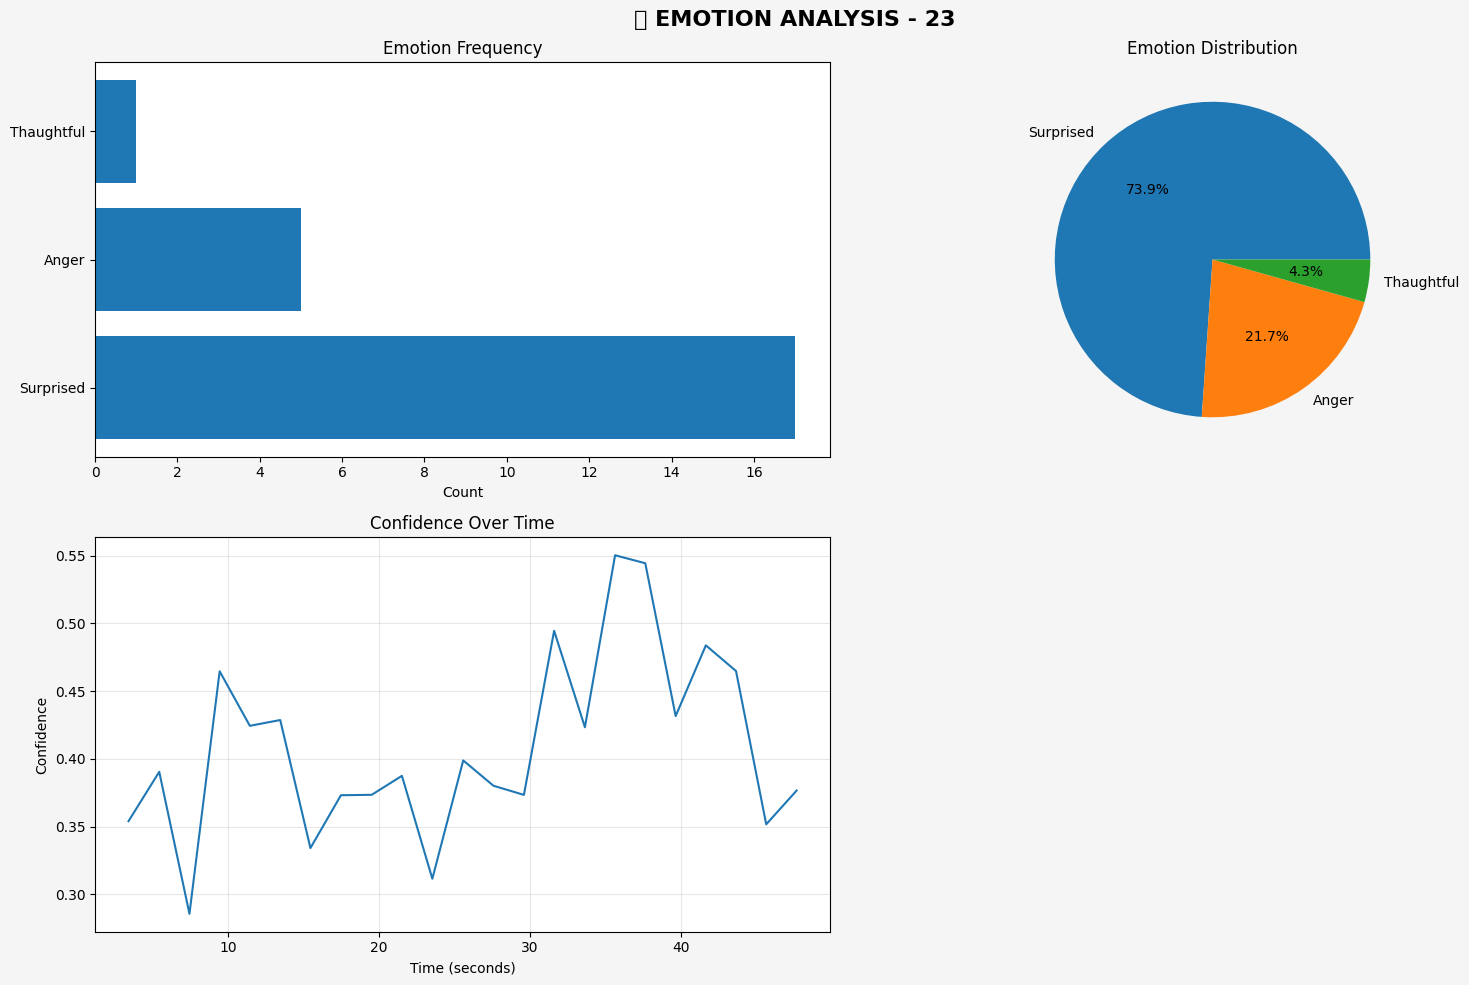


✅ VISUALIZATION COMPLETE

💾 Report saved: emotion_report_23_20260104_004709.json

✨ Clinical session complete!
📋 Patient: 23
📊 Mode: single


In [ ]:
"""
Clinical Emotion Detection System - ADAPTIVE MODE
==================================================
Real-time emotion detection with automatic adaptation:
- DUAL MODE: Compare both models if both are available
- SINGLE MODE: Use whichever model loaded successfully

Press 'q' or 'ESC' to stop recording and generate clinical report.
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from datetime import datetime
import time
import json
import pandas as pd

# Define emotion classes
EMOTION_CLASSES = ['Anger', 'Confused', 'Excited', 'Fear', 'Happy', 'Sadness', 'Surprised', 'Thaughtful']

# Check which detectors are available
has_v3 = 'detector_v3' in globals() and detector_v3 is not None
has_new = 'detector_new' in globals() and detector_new is not None
has_mode = 'detection_mode' in globals()

if not has_v3 and not has_new:
    print(" No detectors available! Please run the previous cell first.")
elif has_v3 and has_new:
    print(" DUAL MODEL MODE - Comparing both models")
    USE_MODE = "dual"
elif has_new:
    print(" SINGLE MODEL MODE - Using New Model (EfficientNet-B0)")
    USE_MODE = "single_new"
else:
    print(" SINGLE MODEL MODE - Using Model V3")
    USE_MODE = "single_v3"


def run_emotion_detection_adaptive(detector_primary, detector_secondary=None, duration_seconds=60, patient_id="", capture_interval=2.0):
    """
    Adaptive emotion detection - works with single or dual models
    
    Args:
        detector_primary: Primary EmotionDetector instance
        detector_secondary: Optional secondary detector for comparison
        duration_seconds: Time limit in seconds
        patient_id: Optional patient identifier
        capture_interval: Seconds between emotion captures (default: 2.0)
    
    Returns:
        Dictionary with analysis results
    """
    is_dual_mode = detector_secondary is not None
    
    # Initialize tracking
    data = {
        'primary': {
            'emotion_timeline': [],
            'emotion_counts': defaultdict(int),
            'confidence_history': [],
            'all_probabilities': []
        }
    }
    
    if is_dual_mode:
        data['secondary'] = {
            'emotion_timeline': [],
            'emotion_counts': defaultdict(int),
            'confidence_history': [],
            'all_probabilities': []
        }
        data['comparison'] = {
            'agreement_count': 0,
            'disagreement_count': 0,
            'agreement_timeline': []
        }
    
    timestamps = []
    start_time = time.time()
    frame_count = 0
    last_capture_time = 0  # Track last emotion capture time
    current_emotion_primary = None  # Store current emotion for display
    current_confidence_primary = 0
    current_result_primary = None
    current_emotion_secondary = None
    current_confidence_secondary = 0
    current_result_secondary = None
    
    # Open webcam
    cap = cv2.VideoCapture(0)
    
    if not cap.isOpened():
        print(" Error: Cannot access camera!")
        return None
    
    # Get patient info
    if not patient_id:
        patient_id = f"Patient_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    
    mode_text = "DUAL MODEL" if is_dual_mode else "SINGLE MODEL"
    print("="*80)
    print(f" {mode_text} CLINICAL EMOTION DETECTION")
    print("="*80)
    print(f" Patient ID: {patient_id}")
    print(f" Session Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    if is_dual_mode:
        print(" Mode: Dual Model Comparison")
    else:
        print(" Mode: Single Model Analysis")
    print(" Camera is active - Recording emotional responses")
    print(f"  Capturing emotion every {capture_interval} seconds")
    print("  Press 'q' or 'ESC' to stop")
    print(f"  Auto-stop after {duration_seconds} seconds")
    print("="*80)
    print("\n TIP: Click on the video window to ensure keyboard input!\n")
    
    window_name = "Clinical Emotion Detection - Press Q or ESC to Stop"
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(window_name, 1400, 800)
    
    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                print(" Error reading frame")
                break
            
            elapsed_time = time.time() - start_time
            if duration_seconds and elapsed_time >= duration_seconds:
                print(f"\n  Recording complete ({duration_seconds}s)")
                break
            
            # Check if it's time to capture emotion (every 2 seconds)
            should_capture = (elapsed_time - last_capture_time) >= capture_interval
            
            if should_capture:
                # Make predictions
                result_primary = detector_primary.predict(frame, detect_face=True)
                result_secondary = detector_secondary.predict(frame, detect_face=True) if detector_secondary else None
                
                # Update current display values
                current_result_primary = result_primary
                current_emotion_primary = result_primary['emotion']
                current_confidence_primary = result_primary['confidence']
                
                # Store primary results
                data['primary']['emotion_timeline'].append(current_emotion_primary)
                data['primary']['emotion_counts'][current_emotion_primary] += 1
                data['primary']['confidence_history'].append(current_confidence_primary)
                data['primary']['all_probabilities'].append(result_primary['probabilities'])
                
                # Store secondary results if available
                if result_secondary:
                    current_result_secondary = result_secondary
                    current_emotion_secondary = result_secondary['emotion']
                    current_confidence_secondary = result_secondary['confidence']
                    data['secondary']['emotion_timeline'].append(current_emotion_secondary)
                    data['secondary']['emotion_counts'][current_emotion_secondary] += 1
                    data['secondary']['confidence_history'].append(current_confidence_secondary)
                    data['secondary']['all_probabilities'].append(result_secondary['probabilities'])
                    
                    # Track agreement
                    agree = current_emotion_primary == current_emotion_secondary
                    data['comparison']['agreement_timeline'].append(agree)
                    if agree:
                        data['comparison']['agreement_count'] += 1
                    else:
                        data['comparison']['disagreement_count'] += 1
                
                timestamps.append(elapsed_time)
                frame_count += 1
                last_capture_time = elapsed_time
                
                print(f" Captured emotion at {elapsed_time:.1f}s: {current_emotion_primary} ({current_confidence_primary:.1%})")
            
            # Skip display if no emotion captured yet
            if current_result_primary is None:
                cv2.imshow(window_name, frame)
                key = cv2.waitKey(1) & 0xFF
                if key == ord('q') or key == ord('Q') or key == 27:
                    print("\n✓ Session stopped by clinician")
                    break
                continue
            
            # Create display
            display_frame = frame.copy()
            h, w = display_frame.shape[:2]
            
            if is_dual_mode:
                # DUAL MODE: Split screen layout
                panel_width = 380
                panel_height = min(h - 20, 500)
                
                # Left panel - Primary
                draw_model_panel(display_frame, current_result_primary, current_confidence_primary, current_emotion_primary,
                               x=10, y=10, width=panel_width, height=panel_height,
                               title="PRIMARY", color=(100, 150, 255))
                
                # Right panel - Secondary
                draw_model_panel(display_frame, current_result_secondary, current_confidence_secondary, current_emotion_secondary,
                               x=w-panel_width-10, y=10, width=panel_width, height=panel_height,
                               title="SECONDARY", color=(100, 255, 150))
                
                # Bottom center - Agreement
                agreement_pct = (data['comparison']['agreement_count'] / frame_count * 100) if frame_count > 0 else 0
                agree = current_emotion_primary == current_emotion_secondary
                draw_agreement_panel(display_frame, agree, agreement_pct, elapsed_time, frame_count, h, w)
            else:
                # SINGLE MODE: One panel on right
                panel_width = 420
                panel_height = min(h - 20, 500)
                panel_x = w - panel_width - 10
                panel_y = 10
                
                overlay = display_frame.copy()
                cv2.rectangle(overlay, (panel_x, panel_y),
                            (panel_x + panel_width, panel_y + panel_height),
                            (20, 20, 20), -1)
                cv2.addWeighted(overlay, 0.75, display_frame, 0.25, 0, display_frame)
                
                cv2.rectangle(display_frame, (panel_x, panel_y),
                            (panel_x + panel_width, panel_y + panel_height),
                            (100, 200, 255), 2)
                
                text_x = panel_x + 15
                text_y = panel_y + 30
                line_height = 28
                
                cv2.putText(display_frame, "CLINICAL ANALYSIS",
                           (text_x, text_y), cv2.FONT_HERSHEY_DUPLEX,
                           0.7, (100, 200, 255), 2)
                text_y += 35
                
                cv2.line(display_frame, (panel_x + 10, text_y - 5),
                        (panel_x + panel_width - 10, text_y - 5),
                        (100, 200, 255), 1)
                text_y += 10
                
                cv2.putText(display_frame, f"EMOTION:",
                           (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX,
                           0.55, (200, 200, 200), 1)
                text_y += line_height
                
                emotion_color = (0, 255, 100) if current_confidence_primary > 0.5 else (100, 200, 255)
                cv2.putText(display_frame, f"{current_emotion_primary}",
                           (text_x + 10, text_y), cv2.FONT_HERSHEY_DUPLEX,
                           0.9, emotion_color, 2)
                text_y += line_height + 5
                
                cv2.putText(display_frame, f"Confidence: {current_confidence_primary:.1%}",
                           (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX,
                           0.5, (150, 255, 255), 1)
                text_y += line_height + 10
                
                # Session info
                next_capture = capture_interval - (elapsed_time - last_capture_time)
                cv2.putText(display_frame, f"Time: {elapsed_time:.0f}s / {duration_seconds}s",
                           (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX,
                           0.45, (200, 200, 200), 1)
                text_y += line_height - 5
                
                cv2.putText(display_frame, f"Captures: {frame_count}",
                           (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX,
                           0.45, (200, 200, 200), 1)
                text_y += line_height - 5
                
                cv2.putText(display_frame, f"Next: {next_capture:.1f}s",
                           (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX,
                           0.45, (100, 255, 255), 1)
                text_y += line_height + 5
                
                # Top emotions
                cv2.line(display_frame, (panel_x + 10, text_y - 3),
                        (panel_x + panel_width - 10, text_y - 3),
                        (80, 80, 80), 1)
                text_y += 12
                
                cv2.putText(display_frame, "TOP EMOTIONS:",
                           (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX,
                           0.5, (200, 200, 200), 1)
                text_y += line_height - 2
                
                sorted_emotions = sorted(current_result_primary['probabilities'].items(),
                                       key=lambda x: x[1], reverse=True)[:5]
                
                for emo, prob in sorted_emotions:
                    emo_short = emo[:8]
                    cv2.putText(display_frame, f"{emo_short}:",
                               (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX,
                               0.42, (180, 180, 180), 1)
                    
                    bar_x = text_x + 90
                    bar_y = text_y - 12
                    bar_width = 200
                    bar_height = 16
                    bar_fill = int(prob * bar_width)
                    
                    if prob > 0.5:
                        bar_color = (50, 255, 50)
                    elif prob > 0.3:
                        bar_color = (100, 200, 255)
                    else:
                        bar_color = (150, 150, 150)
                    
                    cv2.rectangle(display_frame, (bar_x, bar_y),
                                 (bar_x + bar_width, bar_y + bar_height),
                                 (60, 60, 60), -1)
                    
                    if bar_fill > 0:
                        cv2.rectangle(display_frame, (bar_x, bar_y),
                                     (bar_x + bar_fill, bar_y + bar_height),
                                     bar_color, -1)
                    
                    cv2.rectangle(display_frame, (bar_x, bar_y),
                                 (bar_x + bar_width, bar_y + bar_height),
                                 (100, 100, 100), 1)
                    
                    cv2.putText(display_frame, f"{prob:.0%}",
                               (bar_x + bar_width + 8, text_y),
                               cv2.FONT_HERSHEY_SIMPLEX,
                               0.4, (180, 180, 180), 1)
                    
                    text_y += 22
            
            # Recording indicator
            cv2.circle(display_frame, (30, 30), 12, (0, 0, 255), -1)
            cv2.circle(display_frame, (30, 30), 12, (255, 255, 255), 2)
            cv2.putText(display_frame, "REC", (50, 37),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
            
            cv2.imshow(window_name, display_frame)
            
            key = cv2.waitKey(1) & 0xFF
            if key == ord('q') or key == ord('Q') or key == 27:
                print("\n✓ Session stopped by clinician")
                break
    
    except KeyboardInterrupt:
        print("\n✓ Session interrupted")
    
    finally:
        cap.release()
        cv2.destroyAllWindows()
        cv2.waitKey(1)
    
    if frame_count == 0:
        print(" No frames were captured!")
        return None
    
    total_time = time.time() - start_time
    
    print("\n" + "="*80)
    print(" GENERATING CLINICAL ANALYSIS REPORT")
    print("="*80)
    print(f"✓ Total emotion captures: {frame_count}")
    print(f"✓ Session duration: {total_time:.2f} seconds")
    print(f"✓ Capture interval: {capture_interval} seconds")
    if is_dual_mode:
        agreement_pct = (data['comparison']['agreement_count'] / frame_count * 100) if frame_count > 0 else 0
        print(f"✓ Model agreement: {data['comparison']['agreement_count']}/{frame_count} ({agreement_pct:.1f}%)")
    print("="*80)
    
    # Create visualization
    report = {
        'patient_id': patient_id,
        'session_date': datetime.now().isoformat(),
        'mode': 'dual' if is_dual_mode else 'single',
        'total_time': total_time,
        'capture_count': frame_count,
        'capture_interval': capture_interval,
        'primary_model_data': {
            'emotion_counts': dict(data['primary']['emotion_counts']),
            'mean_confidence': float(np.mean(data['primary']['confidence_history']))
        }
    }
    
    if is_dual_mode:
        report['secondary_model_data'] = {
            'emotion_counts': dict(data['secondary']['emotion_counts']),
            'mean_confidence': float(np.mean(data['secondary']['confidence_history']))
        }
        report['comparison'] = {
            'agreement_count': data['comparison']['agreement_count'],
            'disagreement_count': data['comparison']['disagreement_count'],
            'agreement_percentage': float((data['comparison']['agreement_count'] / frame_count * 100)) if frame_count > 0 else 0
        }
    
    # Create basic visualization
    visualize_results(data, timestamps, total_time, patient_id, frame_count, is_dual_mode)
    
    # Save report
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    filename = f"emotion_report_{patient_id}_{timestamp}.json"
    with open(filename, 'w') as f:
        json.dump(report, f, indent=2)
    print(f"\n Report saved: {filename}")
    
    return report


def draw_model_panel(frame, result, confidence, emotion, x, y, width, height, title, color):
    """Draw a model result panel on the frame"""
    h_frame = frame.shape[0]
    
    overlay = frame.copy()
    cv2.rectangle(overlay, (x, y), (x + width, y + height), (30, 30, 30), -1)
    cv2.addWeighted(overlay, 0.8, frame, 0.2, 0, frame)
    
    cv2.rectangle(frame, (x, y), (x + width, y + height), color, 3)
    
    text_x = x + 15
    text_y = y + 30
    line_height = 26
    
    cv2.putText(frame, title, (text_x, text_y), cv2.FONT_HERSHEY_DUPLEX, 0.7, color, 2)
    text_y += 35
    
    cv2.line(frame, (x + 10, text_y - 5), (x + width - 10, text_y - 5), color, 1)
    text_y += 10
    
    cv2.putText(frame, f"EMOTION:", (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
    text_y += line_height
    
    emotion_color = (0, 255, 100) if confidence > 0.5 else (100, 200, 255)
    cv2.putText(frame, f"{emotion}", (text_x + 10, text_y), cv2.FONT_HERSHEY_DUPLEX, 0.8, emotion_color, 2)
    text_y += line_height + 5
    
    cv2.putText(frame, f"Confidence: {confidence:.1%}", (text_x, text_y),
               cv2.FONT_HERSHEY_SIMPLEX, 0.48, (150, 255, 255), 1)


def draw_agreement_panel(frame, agree, agreement_pct, elapsed_time, frame_count, h, w):
    """Draw agreement status panel"""
    status_panel_w = 500
    status_panel_h = 120
    status_x = (w - status_panel_w) // 2
    status_y = h - status_panel_h - 10
    
    overlay = frame.copy()
    cv2.rectangle(overlay, (status_x, status_y),
                (status_x + status_panel_w, status_y + status_panel_h),
                (25, 25, 25), -1)
    cv2.addWeighted(overlay, 0.85, frame, 0.15, 0, frame)
    
    border_color = (0, 255, 0) if agree else (0, 100, 255)
    cv2.rectangle(frame, (status_x, status_y),
                (status_x + status_panel_w, status_y + status_panel_h),
                border_color, 3)
    
    text_x = status_x + 20
    text_y = status_y + 35
    
    status_text = "✓ MODELS AGREE" if agree else "✗ MODELS DIFFER"
    text_color = (0, 255, 0) if agree else (100, 200, 255)
    cv2.putText(frame, status_text, (text_x, text_y),
               cv2.FONT_HERSHEY_DUPLEX, 0.8, text_color, 2)
    text_y += 30
    
    cv2.putText(frame, f"Overall Agreement: {agreement_pct:.1f}%",
               (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (200, 200, 200), 1)
    text_y += 25
    
    cv2.putText(frame, f"Time: {elapsed_time:.0f}s | Frames: {frame_count}",
               (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (180, 180, 180), 1)


def visualize_results(data, timestamps, total_time, patient_id, frame_count, is_dual):
    """Create visualization based on available data"""
    
    if is_dual:
        # Dual model visualization
        fig = plt.figure(figsize=(20, 12))
        fig.patch.set_facecolor('#f5f5f5')
        
        # Plot timelines, distributions, etc.
        # (Simplified version)
        ax1 = plt.subplot(2, 3, 1)
        ax1.bar(data['primary']['emotion_counts'].keys(),
               data['primary']['emotion_counts'].values())
        ax1.set_title('Primary Model Distribution')
        ax1.set_xlabel('Emotion')
        ax1.set_ylabel('Count')
        
        ax2 = plt.subplot(2, 3, 2)
        ax2.bar(data['secondary']['emotion_counts'].keys(),
               data['secondary']['emotion_counts'].values())
        ax2.set_title('Secondary Model Distribution')
        ax2.set_xlabel('Emotion')
        ax2.set_ylabel('Count')
        
        ax3 = plt.subplot(2, 3, 3)
        agreement_pct = (data['comparison']['agreement_count'] / frame_count * 100)
        ax3.pie([data['comparison']['agreement_count'], data['comparison']['disagreement_count']],
               labels=['Agree', 'Disagree'], autopct='%1.1f%%',
               colors=['#4caf50', '#ff9800'])
        ax3.set_title(f'Agreement: {agreement_pct:.1f}%')
        
        fig.suptitle(f'🔬 DUAL MODEL COMPARISON - {patient_id}',
                    fontsize=16, fontweight='bold')
    else:
        # Single model visualization
        fig = plt.figure(figsize=(16, 10))
        fig.patch.set_facecolor('#f5f5f5')
        
        ax1 = plt.subplot(2, 2, 1)
        emotions_sorted = sorted(data['primary']['emotion_counts'].items(),
                                key=lambda x: x[1], reverse=True)
        if emotions_sorted:
            emos, counts = zip(*emotions_sorted)
            ax1.barh(emos, counts)
            ax1.set_title('Emotion Frequency')
            ax1.set_xlabel('Count')
        
        ax2 = plt.subplot(2, 2, 2)
        ax2.pie(data['primary']['emotion_counts'].values(),
               labels=data['primary']['emotion_counts'].keys(),
               autopct='%1.1f%%')
        ax2.set_title('Emotion Distribution')
        
        ax3 = plt.subplot(2, 2, 3)
        ax3.plot(timestamps, data['primary']['confidence_history'])
        ax3.set_title('Confidence Over Time')
        ax3.set_xlabel('Time (seconds)')
        ax3.set_ylabel('Confidence')
        ax3.grid(True, alpha=0.3)
        
        fig.suptitle(f'🎯 EMOTION ANALYSIS - {patient_id}',
                    fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\n VISUALIZATION COMPLETE")


# Run detection
print("\n" + ""*40)
print("   CLINICAL EMOTION DETECTION SYSTEM")
print(""*40 + "\n")

# Check if ensemble is available
use_ensemble = 'ensemble_detector' in globals() and ensemble_detector is not None

if use_ensemble and len(ensemble_detector.detectors) > 1:
    print("🔬 ENSEMBLE MODE - Using combined model for higher accuracy!")
    print(f"   Models: {len(ensemble_detector.detectors)}")
    print(f"   Method: {ensemble_detector.method}")
    print(f"   Expected accuracy boost: 3-8%\n")
elif use_ensemble:
    print(" SINGLE MODEL MODE - Using best available model\n")
elif has_new or has_v3:
    print("  Using individual detectors (run previous cell to create ensemble)\n")
else:
    print(" No detectors available! Please run the previous cells first.")
    raise RuntimeError("No detectors available")

patient_id = input("Enter Patient ID (press Enter to auto-generate): ").strip()

# Use ensemble detector if available, otherwise fall back to individual detectors
if use_ensemble:
    results = run_emotion_detection_adaptive(ensemble_detector, None,
                                            duration_seconds=60, patient_id=patient_id)
elif USE_MODE == "dual":
    results = run_emotion_detection_adaptive(detector_new, detector_v3,
                                            duration_seconds=60, patient_id=patient_id)
elif USE_MODE == "single_new":
    results = run_emotion_detection_adaptive(detector_new, None,
                                            duration_seconds=60, patient_id=patient_id)
else:
    results = run_emotion_detection_adaptive(detector_v3, None,
                                            duration_seconds=60, patient_id=patient_id)

if results:
    print("\n✨ Clinical session complete!")
    print(f" Patient: {results['patient_id']}")
    print(f" Mode: {results['mode']}")
    if use_ensemble and len(ensemble_detector.detectors) > 1:
        print(f" Ensemble: {len(ensemble_detector.detectors)} models combined")
        print(f"   Method: {ensemble_detector.method}")
    elif results['mode'] == 'dual':
        print(f" Agreement: {results['comparison']['agreement_percentage']:.1f}%")
